In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print('NumPy version:', np.__version__)


NumPy version: 1.21.6


## 1. 函数定义

这里定义目标函数：

$f(x)=\sin(2.5x)+0.2x^3-0.3x$

In [2]:
def target_function(x: np.ndarray) -> np.ndarray:
    return np.sin(2.5 * x) + 0.2 * x ** 3 - 0.3 * x

# 2. 数据采样
n_train = 600
n_test = 200
x_low, x_high = -3.0, 3.0

x_train = np.random.uniform(x_low, x_high, size=(n_train, 1)).astype(np.float32)
y_train_clean = target_function(x_train).astype(np.float32)
noise = np.random.normal(0.0, 0.05, size=y_train_clean.shape).astype(np.float32)
y_train = y_train_clean + noise

x_test = np.linspace(x_low, x_high, n_test, dtype=np.float32).reshape(-1, 1)
y_test = target_function(x_test).astype(np.float32)

print('Train set:', x_train.shape, y_train.shape)
print('Test set :', x_test.shape, y_test.shape)


Train set: (600, 1) (600, 1)
Test set : (200, 1) (200, 1)


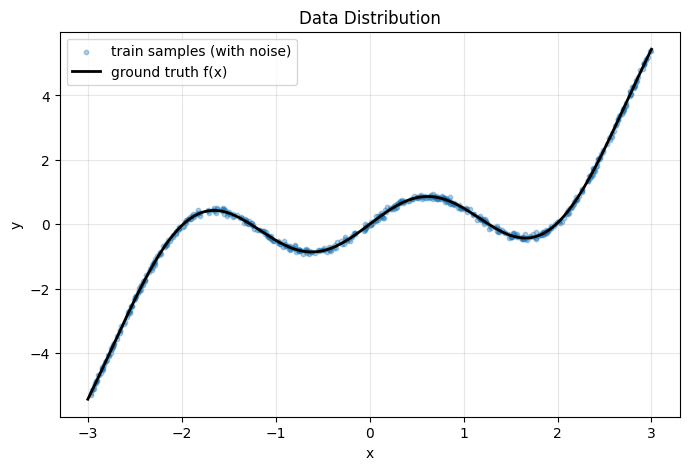

In [3]:
# 训练/测试数据分布可视化
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s=10, alpha=0.35, label='train samples (with noise)')
plt.plot(x_test, y_test, color='black', linewidth=2, label='ground truth f(x)')
plt.title('Data Distribution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. 模型描述

使用纯 NumPy 实现一个两层 ReLU 隐藏层的前馈网络：

- 输入维度：1
- 隐藏层：128 -> ReLU -> 128 -> ReLU
- 输出维度：1

损失函数采用 MSE，优化器使用 mini-batch 梯度下降


In [4]:
class NumpyReLURegressor:
    def __init__(self, in_dim=1, h1=128, h2=128, out_dim=1, seed=42):
        rng = np.random.default_rng(seed)

        # He 初始化（适配 ReLU）
        self.W1 = (rng.standard_normal((in_dim, h1)) * np.sqrt(2.0 / in_dim)).astype(np.float32)
        self.b1 = np.zeros((1, h1), dtype=np.float32)

        self.W2 = (rng.standard_normal((h1, h2)) * np.sqrt(2.0 / h1)).astype(np.float32)
        self.b2 = np.zeros((1, h2), dtype=np.float32)

        self.W3 = (rng.standard_normal((h2, out_dim)) * np.sqrt(2.0 / h2)).astype(np.float32)
        self.b3 = np.zeros((1, out_dim), dtype=np.float32)

    @staticmethod
    def relu(x):
        return np.maximum(0.0, x)

    @staticmethod
    def relu_grad(x):
        return (x > 0).astype(np.float32)

    def forward(self, x):
        z1 = x @ self.W1 + self.b1
        a1 = self.relu(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = self.relu(z2)

        y_hat = a2 @ self.W3 + self.b3
        cache = (x, z1, a1, z2, a2, y_hat)
        return y_hat, cache

    def mse_loss(self, y_hat, y):
        return np.mean((y_hat - y) ** 2)

    def backward(self, cache, y_true, weight_decay=1e-5):
        x, z1, a1, z2, a2, y_hat = cache
        batch_size = x.shape[0]

        d_yhat = (2.0 / batch_size) * (y_hat - y_true)

        dW3 = a2.T @ d_yhat + weight_decay * self.W3
        db3 = np.sum(d_yhat, axis=0, keepdims=True)

        da2 = d_yhat @ self.W3.T
        dz2 = da2 * self.relu_grad(z2)

        dW2 = a1.T @ dz2 + weight_decay * self.W2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.relu_grad(z1)

        dW1 = x.T @ dz1 + weight_decay * self.W1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        grads = {
            'W1': dW1, 'b1': db1,
            'W2': dW2, 'b2': db2,
            'W3': dW3, 'b3': db3,
        }
        return grads

    def step(self, grads, lr=1e-3):
        self.W1 -= lr * grads['W1']
        self.b1 -= lr * grads['b1']
        self.W2 -= lr * grads['W2']
        self.b2 -= lr * grads['b2']
        self.W3 -= lr * grads['W3']
        self.b3 -= lr * grads['b3']

    def predict(self, x):
        y_hat, _ = self.forward(x)
        return y_hat


In [5]:
# 训练
model = NumpyReLURegressor(in_dim=1, h1=128, h2=128, out_dim=1, seed=42)

num_epochs = 3000
batch_size = 64
lr = 1e-3
weight_decay = 1e-5

loss_history = []
num_train = x_train.shape[0]

for epoch in range(1, num_epochs + 1):
    perm = np.random.permutation(num_train)
    x_shuf = x_train[perm]
    y_shuf = y_train[perm]

    epoch_loss_acc = 0.0
    seen = 0

    for start in range(0, num_train, batch_size):
        end = min(start + batch_size, num_train)
        xb = x_shuf[start:end]
        yb = y_shuf[start:end]

        y_hat, cache = model.forward(xb)
        loss = model.mse_loss(y_hat, yb)

        grads = model.backward(cache, yb, weight_decay=weight_decay)
        model.step(grads, lr=lr)

        epoch_loss_acc += loss * (end - start)
        seen += (end - start)

    epoch_loss = epoch_loss_acc / seen
    loss_history.append(epoch_loss)

    if epoch % 300 == 0 or epoch == 1:
        print(f'Epoch [{epoch:4d}/{num_epochs}], Train MSE: {epoch_loss:.6f}')


Epoch [   1/3000], Train MSE: 4.719148
Epoch [ 300/3000], Train MSE: 1.293802
Epoch [ 600/3000], Train MSE: 1.102250
Epoch [ 900/3000], Train MSE: 0.709504
Epoch [1200/3000], Train MSE: 0.244101
Epoch [1500/3000], Train MSE: 0.081010
Epoch [1800/3000], Train MSE: 0.029828
Epoch [2100/3000], Train MSE: 0.021096
Epoch [2400/3000], Train MSE: 0.011412
Epoch [2700/3000], Train MSE: 0.007424
Epoch [3000/3000], Train MSE: 0.003913


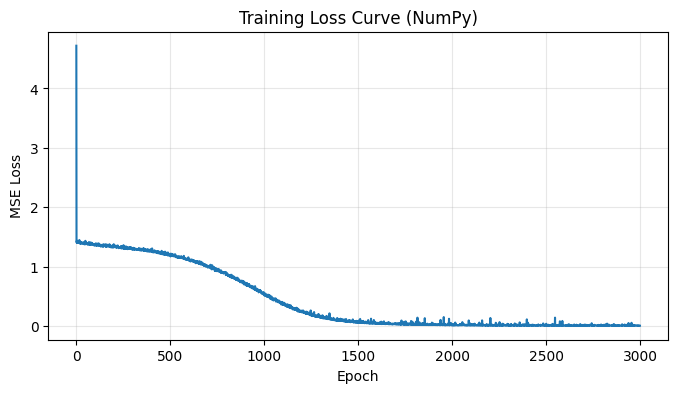

In [6]:
# 训练过程损失曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training Loss Curve (NumPy)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(alpha=0.3)
plt.show()


Test MSE: 0.001508
Test MAE: 0.031431


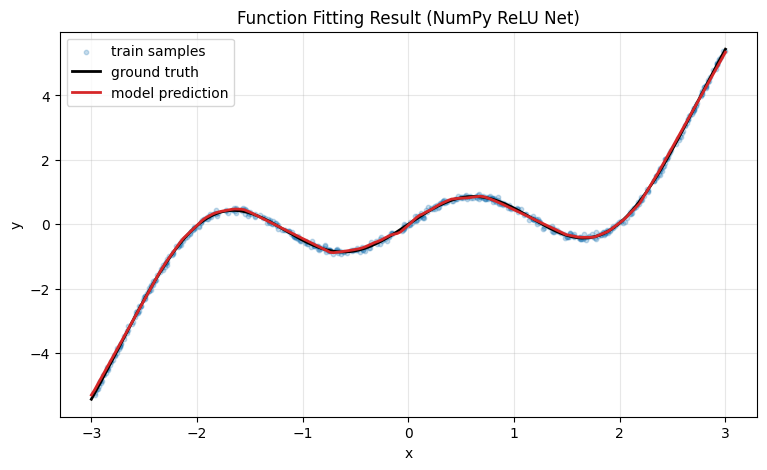

In [7]:
# 4. 测试集评估 + 拟合效果可视化
y_pred_test = model.predict(x_test)

test_mse = np.mean((y_pred_test - y_test) ** 2)
test_mae = np.mean(np.abs(y_pred_test - y_test))

print(f'Test MSE: {test_mse:.6f}')
print(f'Test MAE: {test_mae:.6f}')

plt.figure(figsize=(9, 5))
plt.scatter(x_train, y_train, s=10, alpha=0.25, label='train samples')
plt.plot(x_test, y_test, color='black', linewidth=2, label='ground truth')
plt.plot(x_test, y_pred_test, color='tab:red', linewidth=2, label='model prediction')
plt.title('Function Fitting Result (NumPy ReLU Net)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
